In [103]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

In [104]:
#Introduction
# 1. Introduction
# 2. Data Collection
# 3. Feature Engineering
# 4. Unsupervised Learning: Regime Detection
# 5. Results
# 6. Discussion: Risk and Portfolio Implications
# 7. Conclusion

In [105]:
ticker = "^FTSE"
start = "2006-01-01"
end = None

df = yf.download(ticker, start=start, end=end)
df = df[["Open", "High", "Low", "Close", "Volume"]].dropna()

if isinstance(df.columns, pd.MultiIndex):
    df.columns = [f"{a}_{b}" for a, b in df.columns]
else:
    df.columns = [str(c) for c in df.columns]

df.head()


[*********************100%***********************]  1 of 1 completed


,Open_^FTSE,High_^FTSE,Low_^FTSE,Close_^FTSE,Volume_^FTSE
Date,,,,,
2006-01-03,5618.799805,5682.200195,5618.799805,5681.500000,1838004900
2006-01-04,5681.500000,5716.399902,5681.500000,5714.600098,2005345100
2006-01-05,5714.600098,5722.399902,5686.399902,5691.200195,1862546800
2006-01-06,5691.200195,5731.799805,5691.200195,5731.799805,1894952000
2006-01-09,5731.799805,5750.299805,5725.899902,5731.500000,1690826300


In [106]:
df.isna().sum()

Open_^FTSE      0
High_^FTSE      0
Low_^FTSE       0
Close_^FTSE     0
Volume_^FTSE    0
dtype: int64

In [107]:
vol_window = 21  # ~1 trading month (changeable)

df["ret"] = np.log(df["Close_^FTSE"]).diff()
df["vol"] = df["ret"].rolling(vol_window).std()          # rolling daily vol
df["vol_ann"] = df["vol"] * np.sqrt(252)                 # annualized vol
df["ret2"] = df["ret"]**2
df["ret_mean"] = df["ret"].rolling(vol_window).mean()
df["vol_chg"] = np.log(df["Volume_^FTSE"]).diff()

feat = df.dropna().copy()
feat[["ret","vol","vol_ann","ret2","ret_mean","vol_chg"]].describe()


,ret,vol,vol_ann,ret2,ret_mean,vol_chg
count,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000,5019.000000
mean,0.000103,0.009629,0.152860,0.000125,0.000104,NaN
std,0.011183,0.005809,0.092210,0.000439,0.002156,NaN
min,-0.115117,0.002536,0.040256,0.000000,-0.018752,-inf
25%,-0.004708,0.006093,0.096731,0.000005,-0.000867,-0.149408
50%,0.000528,0.008038,0.127599,0.000026,0.000298,0.000537
75%,0.005508,0.011261,0.178756,0.000096,0.001373,0.154841
max,0.093842,0.050682,0.804555,0.013252,0.007344,inf


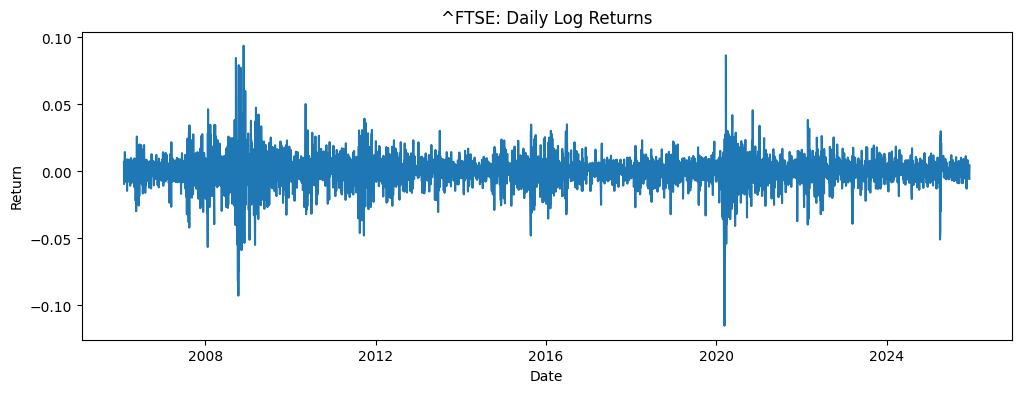

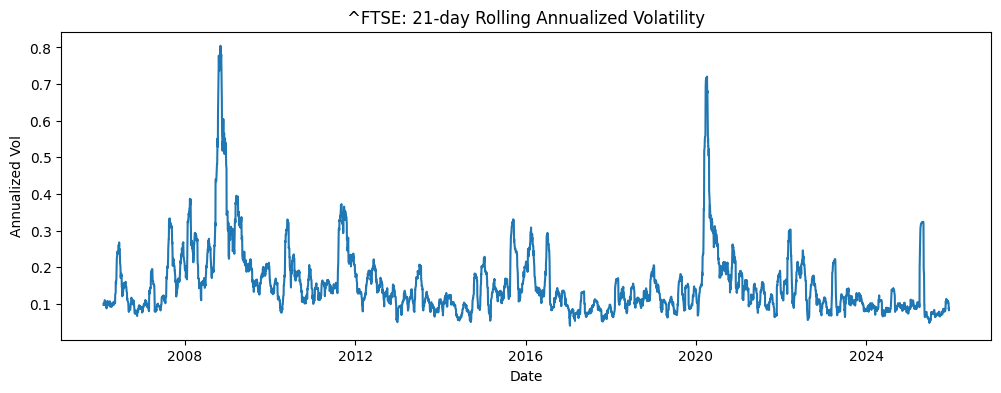

In [108]:
plt.figure(figsize=(12,4))
plt.plot(feat.index, feat["ret"])
plt.title(f"{ticker}: Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

plt.figure(figsize=(12,4))
plt.plot(feat.index, feat["vol_ann"])
plt.title(f"{ticker}: {vol_window}-day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Vol")
plt.show()


In [109]:
# For “volatility-driven regimes”, start with volatility features only:
feature_cols = ["vol", "ret2"]     
# alternative (more info, sometimes noisier):
# feature_cols = ["ret", "vol", "ret2", "ret_mean", "vol_chg"]

X = feat[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X.head()


,vol,ret2
Date,,
2006-02-01,0.006116,0.000051
2006-02-02,0.006411,0.000088
2006-02-03,0.006342,0.000004
2006-02-06,0.006178,0.000005
2006-02-07,0.006266,0.000020


In [110]:
k = 3  # 2 = low/high, 3 = low/med/high

gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
labels_raw = gmm.fit_predict(X_scaled)

feat["regime_gmm"] = labels_raw
feat["regime_gmm"].value_counts().sort_index()


regime_gmm
0    2802
1    1841
2     376
Name: count, dtype: int64

In [111]:
k = 3

kmeans = KMeans(n_clusters=k, n_init=20, random_state=0)
labels_raw = kmeans.fit_predict(X_scaled)

feat["regime_kmeans"] = labels_raw
feat["regime_kmeans"].value_counts().sort_index()

# Final regime assignment used in all subsequent analysis (K-Means)
feat["regime_raw"] = feat["regime_kmeans"]


In [112]:
avg_vol = feat.groupby("regime_raw")["vol"].mean().sort_values()
mapping = {old: new for new, old in enumerate(avg_vol.index)}
feat["regime"] = feat["regime_raw"].map(mapping).astype(int)

split_date = "2015-01-01"

train = feat.loc[:split_date]
test = feat.loc[split_date:]

train_dist = train["regime"].value_counts(normalize=True)
test_dist = test["regime"].value_counts(normalize=True)

train_dist, test_dist

feat.groupby("regime")["vol_ann"].mean()


regime
0    0.125724
1    0.328017
2    0.596286
Name: vol_ann, dtype: float64

In [113]:
summary = feat.groupby("regime").agg(
    n_days=("ret", "count"),
    mean_daily_ret=("ret", "mean"),
    std_daily_ret=("ret", "std"),
    mean_ann_vol=("vol_ann", "mean"),
    worst_day=("ret", "min"),
    best_day=("ret", "max"),
)


from scipy import stats

low_regime = feat.loc[feat["regime"] == 0, "ret"]
high_regime = feat.loc[feat["regime"] == feat["regime"].max(), "ret"]

t_stat, p_val = stats.ttest_ind(
    low_regime,
    high_regime,
    equal_var=False,
    nan_policy="omit"
)

t_stat, p_val



summary["ann_ret"] = summary["mean_daily_ret"] * 252
summary["ann_vol_from_ret"] = summary["std_daily_ret"] * np.sqrt(252)
summary["sharpe_like"] = summary["ann_ret"] / (summary["ann_vol_from_ret"] + 1e-12)

summary


,n_days,mean_daily_ret,std_daily_ret,mean_ann_vol,worst_day,best_day,ann_ret,ann_vol_from_ret,sharpe_like
regime,,,,,,,,,
0,4359,0.000197,0.007846,0.125724,-0.032842,0.026664,0.049696,0.124548,0.399009
1,650,-0.000495,0.020874,0.328017,-0.058701,0.060070,-0.124807,0.331368,-0.376642
2,10,-0.002183,0.092001,0.596286,-0.115117,0.093842,-0.550033,1.460465,-0.376615


In [114]:
date_summary = feat.groupby("regime").agg(
    start_date=("ret", lambda x: x.index.min()),
    end_date=("ret", lambda x: x.index.max()),
    n_days=("ret", "count")
)

date_summary

,start_date,end_date,n_days
regime,,,
0,2006-02-01,2025-12-12,4359
1,2006-05-23,2025-05-08,650
2,2008-09-19,2020-03-24,10


In [115]:
feat["regime_change"] = feat["regime"].ne(feat["regime"].shift())

durations = (
    feat.groupby((feat["regime_change"]).cumsum())
        .agg(
            regime=("regime", "first"),
            start_date=("regime", lambda x: x.index.min()),
            end_date=("regime", lambda x: x.index.max()),
            length=("regime", "count")
        )
)

durations.groupby("regime")["length"].describe()


,count,mean,std,min,25%,50%,75%,max
regime,,,,,,,,
0,83.0,52.518072,131.241572,1.0,2.0,4.0,37.0,908.0
1,91.0,7.142857,13.267815,1.0,1.0,1.0,5.0,73.0
2,9.0,1.111111,0.333333,1.0,1.0,1.0,1.0,2.0


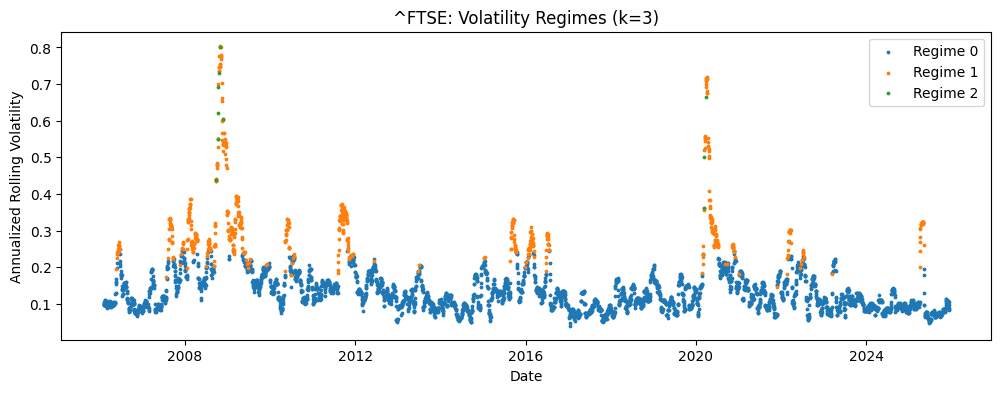

In [116]:
plt.figure(figsize=(12,4))
for r in sorted(feat["regime"].unique()):
    mask = feat["regime"] == r
    plt.scatter(feat.index[mask], feat.loc[mask, "vol_ann"], s=3, label=f"Regime {r}")

plt.title(f"{ticker}: Volatility Regimes (k={k})")
plt.xlabel("Date")
plt.ylabel("Annualized Rolling Volatility")
plt.legend()
plt.show()


In [117]:
high_risk_regime = feat["regime"].max()
feat["high_risk_flag"] = (feat["regime"] == high_risk_regime).astype(int)

risk_compare = feat.groupby("high_risk_flag").agg(
    n_days=("ret", "count"),
    mean_ret=("ret", "mean"),
    ann_vol_mean=("vol_ann", "mean"),
    std_ret=("ret", "std")
)

feat["position"] = np.where(feat["high_risk_flag"] == 1, 0.5, 1.0)
feat["strategy_ret"] = feat["position"] * feat["ret"]

strategy_summary = feat[["ret", "strategy_ret"]].mean() * 252
strategy_summary

risk_compare["ann_ret"] = risk_compare["mean_ret"] * 252
risk_compare["ann_vol_from_ret"] = risk_compare["std_ret"] * np.sqrt(252)

risk_compare


,n_days,mean_ret,ann_vol_mean,std_ret,ann_ret,ann_vol_from_ret
high_risk_flag,,,,,,
0,5009,0.000107,0.151975,0.010492,0.027051,0.166561
1,10,-0.002183,0.596286,0.092001,-0.550033,1.460465


In [118]:
feat.to_csv("ftse_features_with_regimes.csv")
summary.to_csv("ftse_regime_summary.csv")
risk_compare.to_csv("ftse_high_risk_comparison.csv")



In [ ]:
summary_returns = feat[["ret", "strategy_ret"]].mean() * 252
summary_vols = feat[["ret", "strategy_ret"]].std() * np.sqrt(252)

# Table comparing buy/hold vs regime strategy annualized return and vol
strategy_summary = (
    pd.DataFrame({"ann_return": summary_returns, "ann_vol": summary_vols})
    .rename_axis("series")
    .reset_index()
    .assign(
        ann_return_pct=lambda d: d["ann_return"] * 100,
        ann_vol_pct=lambda d: d["ann_vol"] * 100,
    )
    [["series", "ann_return", "ann_vol", "ann_return_pct", "ann_vol_pct"]]
)

strategy_summary
